In [1]:
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, Reset
import matplotlib.pyplot as plt
import math
from scipy.linalg import expm
import numpy as np
from qiskit.circuit.library import RXGate, RYGate, RZGate
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit.quantum_info import Statevector


In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# Save your credentials (do this once)
QiskitRuntimeService.save_account(token="QE7b2pxTfvcXgYR-X6aKBgr7dgphzHsAgb1dx1f9GvFj",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/da3ce4230c4b4856be6be12092de9ebd:bc11b744-41d4-42e6-8234-b8930efb634d::", # Optional
                                  overwrite=True)
from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service
service = QiskitRuntimeService()
 

In [3]:
n=7
circ=QuantumCircuit(n,n)

In [4]:
for i in range(n):
    circ.h(i)
circ.ry(-math.pi/3,0)
circ.cry(-math.pi/3,1,0)
if n % 2==0:
    m=int(n-2)
    for i in range(1,m+1):
      circ.cry(-(2*i)*math.pi/3,i+1,0)
else:
    m=int((n-1))
    for i in range(1,m):
      circ.cry(-(2*i)*math.pi/3,i+1,0)  

print(m)    

6


In [5]:
circ.draw()

┌───┐┌──────────┐┌──────────┐┌───────────┐┌───────────┐┌─────────┐»
q_0: ┤ H ├┤ Ry(-π/3) ├┤ Ry(-π/3) ├┤ Ry(-2π/3) ├┤ Ry(-4π/3) ├┤ Ry(-2π) ├»
     ├───┤└──────────┘└────┬─────┘└─────┬─────┘└─────┬─────┘└────┬────┘»
q_1: ┤ H ├─────────────────■────────────┼────────────┼───────────┼─────»
     ├───┤                              │            │           │     »
q_2: ┤ H ├──────────────────────────────■────────────┼───────────┼─────»
     ├───┤                                           │           │     »
q_3: ┤ H ├───────────────────────────────────────────■───────────┼─────»
     ├───┤                                                       │     »
q_4: ┤ H ├───────────────────────────────────────────────────────■─────»
     ├───┤                                                             »
q_5: ┤ H ├─────────────────────────────────────────────────────────────»
     ├───┤                                                             »
q_6: ┤ H ├─────────────────────────────────────────────────────────────»
     └───┘                                                             »
c: 7/══════════════════════════════════════════════════════════════════»
                                                                       »
«     ┌───────────┐┌────────────┐
«q_0: ┤ Ry(-8π/3) ├┤ Ry(-10π/3) ├
«     └─────┬─────┘└─────┬──────┘
«q_1: ──────┼────────────┼───────
«           │            │       
«q_2: ──────┼────────────┼───────
«           │            │       
«q_3: ──────┼────────────┼───────
«           │            │       
«q_4: ──────┼────────────┼───────
«           │            │       
«q_5: ──────■────────────┼───────
«                        │       
«q_6: ───────────────────■───────
«                                
«c: 7/═══════════════════════════
«

In [6]:
state=Statevector(circ)
print(state)

Statevector([ 0.12074073+0.j,  0.03235238+0.j,  0.12074073+0.j,
             -0.03235238+0.j,  0.08838835+0.j, -0.08838835+0.j,
              0.03235238+0.j, -0.12074073+0.j, -0.03235238+0.j,
             -0.12074073+0.j, -0.08838835+0.j, -0.08838835+0.j,
             -0.12074073+0.j, -0.03235238+0.j, -0.12074073+0.j,
              0.03235238+0.j, -0.12074073+0.j, -0.03235238+0.j,
             -0.12074073+0.j,  0.03235238+0.j, -0.08838835+0.j,
              0.08838835+0.j, -0.03235238+0.j,  0.12074073+0.j,
              0.03235238+0.j,  0.12074073+0.j,  0.08838835+0.j,
              0.08838835+0.j,  0.12074073+0.j,  0.03235238+0.j,
              0.12074073+0.j, -0.03235238+0.j, -0.08838835+0.j,
              0.08838835+0.j, -0.03235238+0.j,  0.12074073+0.j,
              0.03235238+0.j,  0.12074073+0.j,  0.08838835+0.j,
              0.08838835+0.j,  0.12074073+0.j,  0.03235238+0.j,
              0.12074073+0.j, -0.03235238+0.j,  0.08838835+0.j,
             -0.08838835+0.j,  0.0323523

In [7]:
for i in range(n):
    circ.measure(i,i)

In [8]:
backend = service.least_busy(operational=True, simulator=False) 
print(f"Running on backend: {backend.name}")

from qiskit import transpile
qpe_transpiled = transpile(circ, backend)

sampler = SamplerV2(backend)
job = sampler.run([qpe_transpiled])

Running on backend: ibm_kingston


Measurements counts: {'0111010': 61, '0100111': 33, '1100000': 58, '1110010': 58, '1101100': 41, '1011110': 26, '0100011': 52, '0111101': 28, '1111110': 60, '1101001': 41, '1001000': 30, '0000101': 25, '0111100': 36, '0000100': 37, '0101010': 48, '1111011': 43, '0001001': 49, '1100010': 59, '1100101': 33, '1101011': 52, '1101101': 3, '0001100': 47, '0100000': 29, '0010010': 58, '1111001': 57, '1000010': 36, '1010001': 44, '0110000': 31, '0100101': 49, '0011110': 55, '0000111': 63, '1100111': 59, '0101000': 54, '1110111': 70, '1000001': 69, '0010011': 12, '1101010': 31, '0001111': 9, '1000011': 38, '0110011': 49, '1000100': 54, '1000111': 8, '0001110': 57, '1111010': 29, '1010011': 37, '0010111': 56, '0110101': 44, '1001101': 56, '0000110': 10, '0010100': 28, '0011001': 51, '1010000': 9, '0110010': 11, '1010100': 49, '0110001': 26, '0111000': 68, '1010110': 52, '1100011': 10, '1011101': 44, '0111111': 42, '0110100': 7, '0000010': 58, '1010010': 29, '1000110': 70, '0010000': 59, '0001101

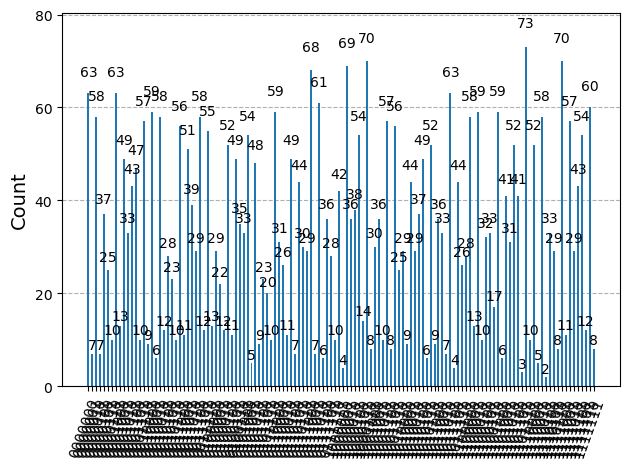

In [9]:

result = job.result()
pub_result = result[0]
counts = pub_result.data.c.get_counts()

print(f"Measurements counts: {counts}")
plot_histogram(counts)